In [1]:
import pandas as pd
import re
import warnings
import string
import joblib
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from bs4 import BeautifulSoup, MarkupResemblesLocatorWarning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, auc
from xgboost import XGBClassifier
warnings.filterwarnings("ignore", category=MarkupResemblesLocatorWarning)

## Funciones

In [2]:
ps = PorterStemmer()

In [3]:
def clean_html(text):
    soup = BeautifulSoup(text, "html.parser")
    return soup.get_text(separator=" ", strip=True)

In [4]:
def remove_urls(text):
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    text = url_pattern.sub(r'', text)
    return text

In [5]:
def eliminate_punctuation(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub('[\u2018\u2019\u201C\u201D\u2013\u2014\u2026]', '', text)
    return text

In [6]:
def stopword_removal(text):
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(filtered_tokens)

In [7]:
def lemmatization(text):
    tokens = word_tokenize(text)
    lemmatized_tokens = [ps.stem(word) for word in tokens]
    return ' '.join(lemmatized_tokens)

In [8]:
def clean_text(text):
    text = clean_html(text)
    text = remove_urls(text)
    text = eliminate_punctuation(text)
    text = stopword_removal(text)
    text = lemmatization(text)
    
    return text

## Exploracion de datos

In [9]:
seed = 666
np.random.seed(seed)

In [10]:
df_fake = pd.read_csv('/home/paul-h-roldan-hernandez/Documentos/Scripts/Deteccion_Noticias_Falsas/Fake_Real_News_Dataset/Fake.csv')
df_true = pd.read_csv('/home/paul-h-roldan-hernandez/Documentos/Scripts/Deteccion_Noticias_Falsas/Fake_Real_News_Dataset/True.csv')

In [11]:
df_fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [12]:
df_true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [13]:
print(df_true.shape)
print(df_fake.shape)

(21417, 4)
(23481, 4)


In [14]:
df_true.isnull().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [15]:
df_fake.isnull().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [16]:
df_true.sample(10)

,title,text,subject,date
13149,"Brazilian prosecutor accuses ex-minister, cong...",SAO PAULO (Reuters) - Brazil s prosecutor gene...,worldnews,"December 5, 2017"
5548,"Trump tax plan to help businesses, working Ame...",WASHINGTON (Reuters) - President Donald Trump’...,politicsNews,"February 9, 2017"
16167,China aims to set up state anti-corruption uni...,BEIJING (Reuters) - China aims to pass a natio...,worldnews,"October 29, 2017"
19877,Singaporeans protest against uncontested presi...,SINGAPORE (Reuters) - Hundreds of Singaporeans...,worldnews,"September 16, 2017"
15431,Assad says Syria war does not end in Deir al-Zor,BEIRUT (Reuters) - Syria s army and its allies...,worldnews,"November 7, 2017"
14441,Zimbabwe war vets threaten to unleash crowds o...,HARARE (Reuters) - The leader of Zimbabwe s po...,worldnews,"November 19, 2017"
29,Senate leader McConnell sees a more collegial ...,WASHINGTON (Reuters) - U.S. Senate Majority Le...,politicsNews,"December 22, 2017"
17324,Britain and France to work to enforce Iran nuc...,LONDON (Reuters) - Britain and France are firm...,worldnews,"October 16, 2017"
15822,Spanish judge orders Catalan leaders to be hel...,MADRID (Reuters) - A Spanish judge on Thursday...,worldnews,"November 2, 2017"
9961,Senate Democrats want changes to House Republi...,WASHINGTON (Reuters) - U.S. Senate Minority Le...,politicsNews,"April 13, 2016"


In [17]:
df_fake.sample(10)

,title,text,subject,date
2305,Photo Of Hillary Reading About Pence’s Privat...,You remember that one company that used to stu...,News,"March 4, 2017"
14549,HYSTERICAL! HILLARY CLINTON Upstaged By Man Be...,A man with stickers on his face must have been...,politics,"Feb 2, 2016"
18367,TRUMP SUPPORTER’S HILARIOUS VIRAL VIDEO Mockin...,Terrance Williams is a conservative Trump supp...,left-news,"Jul 7, 2017"
10691,“DRIVE THEM OUT OF YOUR PLACES OF WORSHIP!” Lo...,President Trump gave a powerful speech to Arab...,politics,"Jun 6, 2017"
17352,HAPPY MOTHER’S DAY…Your First Grader Just Rate...,Rate your mom for Mother s Day sounds like the...,Government News,"May 11, 2015"
3153,Trump Just ADMITTED He Mindlessly Parrots Rus...,Donald Trump once said that he loves the poor...,News,"January 5, 2017"
14891,SHOCKING: Sharia Law Implemented In First Amer...,We live near this once great tourist destinati...,politics,"Nov 25, 2015"
14722,Desperation? The Clinton Grifters Go Back On T...,The World Class Grifters aka The Clintons are ...,politics,"Jan 2, 2016"
22840,"‘Trump, Russia, Possible Collusion’ (REMIX)",Russiagate. First it was Russian hacking our e...,Middle-east,"July 28, 2017"
6618,House Republicans Just Went After Your Retire...,On Thursday Republicans in Congress voted to o...,News,"April 30, 2016"


## Preprocesamiento de datos

In [18]:
df_fake['label'] = 1
df_true['label'] = 0

In [19]:
df = pd.concat([df_true, df_fake], axis=0).reset_index(drop=True)

In [20]:
df.sample(20)

,title,text,subject,date,label
19438,EU officials reach draft deal on more North Ko...,BRUSSELS (Reuters) - EU ambassadors have reach...,worldnews,"September 21, 2017",0
36214,HISPANIC ACTIVISTS Promise To Punish Donald Tr...,Did you know that a record number of illegals ...,politics,"Dec 14, 2015",1
18669,Last flight departs as Iraq imposes ban for Ku...,"ERBIL, Iraq/ANKARA (Reuters) - The last intern...",worldnews,"September 29, 2017",0
32188,“Rise From Your Knees!” Poland’s Prime Ministe...,Bravo! Polish prime minister Beata Szydlo just...,politics,"May 27, 2017",1
34880,GREAT SPEECH! DONALD TRUMP Gets A Dig At Hilla...,If you watched Trumps acceptance speech last n...,politics,"Jul 22, 2016",1
22739,"Officer Who Shot Tamir Rice Finally Fired, Bu...","After more than two years, the Cleveland polic...",News,"May 30, 2017",1
26050,Leaked Emails Show Colin Powell Has STRONG Op...,"Colin Powell is NOT voting for Donald Trump, a...",News,"September 14, 2016",1
227,Trump urges Alabama voters to back Roy Moore,"PENSACOLA, Fla. (Reuters) - U.S. President Don...",politicsNews,"December 9, 2017",0
22289,US Experiences Surge In Hate-Based Incidents ...,Since Donald Trump s November 8 election victo...,News,"July 12, 2017",1
28915,Trump Supporters Form Militia To Beat Up Prot...,Sounds like they should call themselves the Br...,News,"March 14, 2016",1


In [21]:
df.loc[24,'text']

'LIMA (Reuters) - Peru’s President Pedro Pablo Kuczynski could end up the surprise winner of an attempt to oust him from power this week, after some opposition lawmakers broke ranks with party leaders to support him, opening a divide that might strengthen his hand. Despite having a Congressional majority, the rightwing opposition party Popular Force was unable to push through a motion to remove Kuczynski from office on Thursday, after 10 of its own lawmakers broke ranks to save the president. The vote cemented a growing divide in the opposition and looked to threaten its control over Congress, potentially aiding Kuczynski as he tries to restore political stability and revive investments in one of Latin America’s most robust economies. The surprise defection was the result of a deal struck between Kuczynski and Popular Force rebel lawmaker Kenji Fujimori to get his father and ex-president Alberto Fujimori out of prison, alleged Popular Force secretary general, Jose Chlimper. Over the pa

In [22]:
ejemplo= clean_text(df.loc[24]["text"])
print(ejemplo)

lima reuter peru presid pedro pablo kuczynski could end surpris winner attempt oust power week opposit lawmak broke rank parti leader support open divid might strengthen hand despit congression major rightw opposit parti popular forc unabl push motion remov kuczynski offic thursday 10 lawmak broke rank save presid vote cement grow divid opposit look threaten control congress potenti aid kuczynski tri restor polit stabil reviv invest one latin america robust economi surpris defect result deal struck kuczynski popular forc rebel lawmak kenji fujimori get father expresid alberto fujimori prison alleg popular forc secretari gener jose chlimper past year kenji court kuczynski centerright govern challeng sister keiko leadership rightw populist movement father form 1990 defianc sister kenji threw support behind kuczynski ahead vote whether remov offic unproven graft alleg nine popular forc lawmak follow lead birth seriou formal split fujimori movement said guillermo loli head polit research p

In [23]:
df_text_cleaned = df.copy(deep=True)
df_text_cleaned['text'] = df_text_cleaned['text'].apply(clean_text)

In [24]:
df_text_cleaned.duplicated(subset='text').sum()

np.int64(6467)

In [25]:
df_text_cleaned.drop_duplicates(subset='text', inplace=True)

In [26]:
df_text_cleaned.duplicated(subset='text').sum()

np.int64(0)

In [27]:
df_text_cleaned

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",washington reuter head conserv republican fact...,politicsNews,"December 31, 2017",0
1,U.S. military to accept transgender recruits o...,washington reuter transgend peopl allow first ...,politicsNews,"December 29, 2017",0
2,Senior U.S. Republican senator: 'Let Mr. Muell...,washington reuter special counsel investig lin...,politicsNews,"December 31, 2017",0
3,FBI Russia probe helped by Australian diplomat...,washington reuter trump campaign advis georg p...,politicsNews,"December 30, 2017",0
4,Trump wants Postal Service to charge 'much mor...,seattlewashington reuter presid donald trump c...,politicsNews,"December 29, 2017",0
...,...,...,...,...,...
44115,The White House and The Theatrics of ‘Gun Cont...,21st centuri wire say world stage men women me...,US_News,"January 7, 2016",1
44116,Activists or Terrorists? How Media Controls an...,randi johnson 21st centuri wireth major mainst...,US_News,"January 7, 2016",1
44117,"BOILER ROOM – No Surrender, No Retreat, Heads ...",tune altern current radio network acr anoth li...,US_News,"January 6, 2016",1
44118,Federal Showdown Looms in Oregon After BLM Abu...,21st centuri wire say new front open long batt...,US_News,"January 4, 2016",1


In [28]:
x_train, x_test, y_train, y_test = train_test_split(df_text_cleaned['text'], df_text_cleaned['label'], test_size=0.3, random_state=seed)

In [29]:
words_to_delete = [
    "reuter", "said",
    "monday", "tuesday", "wednesday", "thursday", "friday",
    "via", "imag", "image","washington"
]

In [30]:
vectorizer = TfidfVectorizer(
    stop_words = words_to_delete,
    min_df=2, 
    max_df=0.95
)
x_train = vectorizer.fit_transform(x_train)
x_test = vectorizer.transform(x_test)

## Modelos

In [31]:

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, n_jobs=-1),
    'SVC':                 SVC(probability=True),
    'XGBoost':             XGBClassifier(eval_metric='logloss', n_jobs=-1, device ='cuda', random_state=seed)
}

results = {}
for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:, 1]
    results[name] = {
        'model':  model,
        'y_pred': y_pred,
        'y_prob': y_prob
    }

/home/paul-h-roldan-hernandez/Diplo_env/lib/python3.12/site-packages/xgboost/core.py:729: UserWarning: [09:24:48] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [32]:
results

{'Logistic Regression': {'model': LogisticRegression(max_iter=1000, n_jobs=-1),
  'y_pred': array([0, 0, 0, ..., 1, 1, 0]),
  'y_prob': array([0.04009627, 0.10160544, 0.00807435, ..., 0.9974379 , 0.88290953,
         0.19529437])},
 'SVC': {'model': SVC(probability=True),
  'y_pred': array([0, 0, 0, ..., 1, 1, 0]),
  'y_prob': array([2.92162503e-04, 1.22102775e-03, 2.99445467e-05, ...,
         1.00000000e+00, 9.96066097e-01, 2.16755932e-02])},
 'XGBoost': {'model': XGBClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bynode=None,
                colsample_bytree=None, device='cuda', early_stopping_rounds=None,
                enable_categorical=False, eval_metric='logloss',
                feature_types=None, feature_weights=None, gamma=None,
                grow_policy=None, importance_type=None,
                interaction_constraints=None, learning_rate=None, max_bin=None,
                max_cat_threshold=None, max_cat_to_o

In [33]:
roc_data = []
for name, result in results.items():
    fpr, tpr, _ = roc_curve(y_test, result['y_prob'])
    roc_auc = auc(fpr, tpr)
    for f, t in zip(fpr, tpr):
        roc_data.append({'FPR': f, 'TPR': t, 'Model': f'{name} (AUC = {roc_auc:.3f})'})

roc_df = pd.DataFrame(roc_data)

fig = px.line(
    roc_df, x='FPR', y='TPR', color='Model',
    title='ROC Curves — Model Comparison',
    labels={'FPR': 'False Positive Rate', 'TPR': 'True Positive Rate'}
)
fig.add_shape(type='line', x0=0, y0=0, x1=1, y1=1,
              line=dict(dash='dash', color='gray', width=1))
fig.show()

In [34]:
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [accuracy_score(y_test, result['y_pred']) for result in results.values()]
})

In [35]:
results_df

,Model,Accuracy
0,Logistic Regression,0.969037
1,SVC,0.976236
2,XGBoost,0.971032


In [36]:
logistic_model = results['Logistic Regression']['model']

In [37]:
feature_names = vectorizer.get_feature_names_out()
coef = logistic_model.coef_[0]

df_coef = pd.DataFrame({
    "word": feature_names,
    "coef": coef
})

In [38]:
df_coef_sorted_fake = df_coef.sort_values(by="coef", ascending=False).head(10)
df_coef_sorted_real = df_coef.sort_values(by="coef", ascending=True).head(10)

In [39]:
df_coef_sorted_fake

,word,coef
19478,gop,6.612903
16364,even,6.375322
5057,american,5.167026
21385,hillari,4.951883
5036,america,4.899680
29749,mr,4.839448
26440,like,4.774473
16817,fact,4.403968
47319,video,4.116108
48764,wire,4.056436


In [40]:
df_coef_sorted_real

,word,coef
46804,us,-8.210284
14697,dont,-5.715312
41982,statement,-5.397453
35046,presidenti,-5.318848
41654,spokesman,-5.228860
28987,minist,-5.063607
22497,im,-4.973498
44775,told,-4.891959
31370,nov,-4.648616
11484,comment,-4.208269


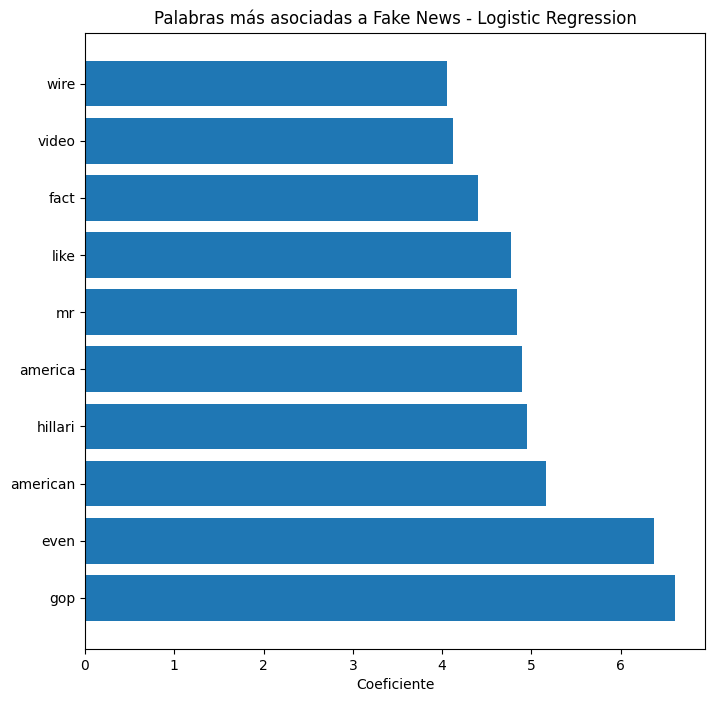

In [41]:
plt.figure(figsize=(8, 8))
plt.barh(df_coef_sorted_fake["word"], df_coef_sorted_fake["coef"])
plt.title("Palabras más asociadas a Fake News - Logistic Regression")
plt.xlabel("Coeficiente")
plt.show()


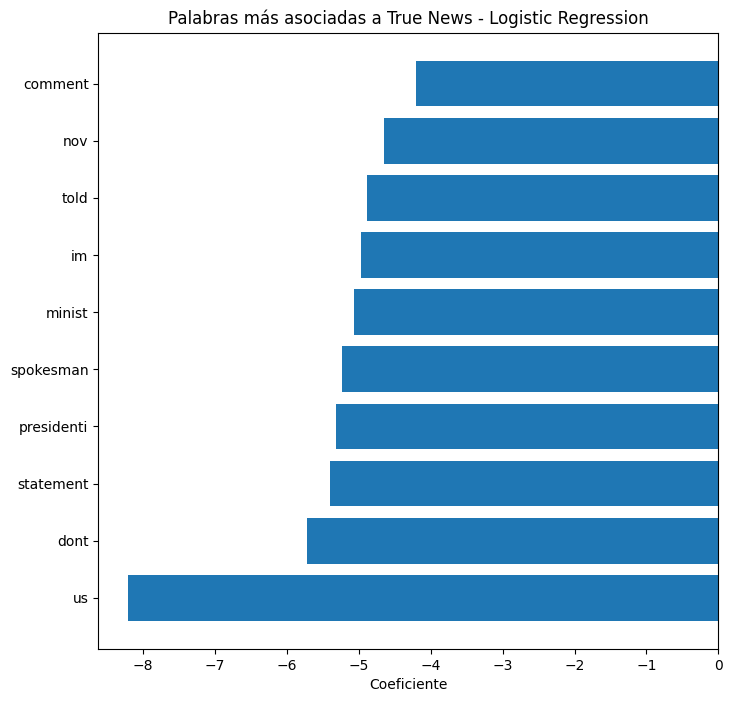

In [42]:
plt.figure(figsize=(8, 8))
plt.barh(df_coef_sorted_real["word"], df_coef_sorted_real["coef"])
plt.title("Palabras más asociadas a True News - Logistic Regression")
plt.xlabel("Coeficiente")
plt.show()

In [43]:
words_to_check = ["us", "american", "even", "gop"]

for word in words_to_check:
    print(f"\nPalabra: {word}")
    print(
        df_text_cleaned
        .assign(contains_word=df_text_cleaned["text"].str.contains(fr"\b{word}\b", regex=True))
        .groupby("label")["contains_word"]
        .mean()
    )


Palabra: us
label
0    0.624964
1    0.371471
Name: contains_word, dtype: float64

Palabra: american
label
0    0.188801
1    0.339792
Name: contains_word, dtype: float64

Palabra: even
label
0    0.164084
1    0.405738
Name: contains_word, dtype: float64

Palabra: gop
label
0    0.003422
1    0.128442
Name: contains_word, dtype: float64
